# GP Prior Plots

This notebook visualises the **Gaussian Process prior** using a squared-exponential (RBF) kernel.

Two plots are shown:
1. The prior mean with a 2-sigma confidence band.
2. The same confidence band overlaid with 3 random draws from the prior.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_creation import generate_gp_plots_data
from gp_utils import gp_posterior_se
from kernels import squared_exponential

In [3]:
# Reproducibility for random GP draws
np.random.seed(42)

# Prior setup (no data)
X_prior = np.linspace(-5.5, 5.5, 200)
ell = 1.0
sf = 1.0
sigma = 2.0

K_prior = squared_exponential(
    X_prior, X_prior, lengthscale=ell, variance=sf ** 2)
prior_mean = np.zeros(len(X_prior))
prior_sd = np.sqrt(np.diag(K_prior))

# Match plotting style from gp_plots.py
sns.set_theme(style="whitegrid", palette="husl")
sns.set_context("notebook", font_scale=1.1)

y_min = np.min(prior_mean - sigma * prior_sd)
y_max = np.max(prior_mean + sigma * prior_sd)
margin = 0.1 * (y_max - y_min)
y_min -= margin
y_max += margin

## Plot 1: GP Prior — Mean with 2-Sigma Confidence Interval

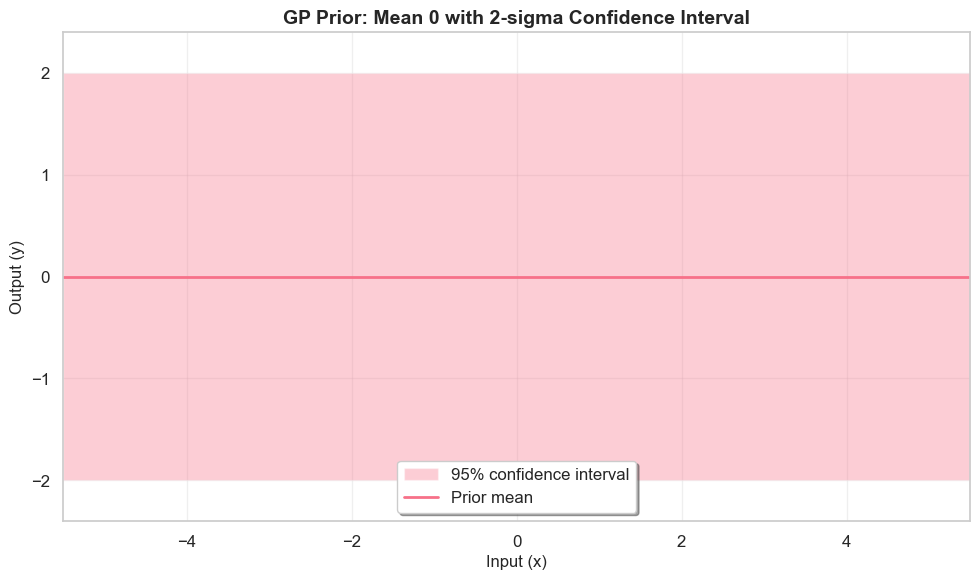

In [4]:
fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.fill_between(
    X_prior,
    prior_mean - sigma * prior_sd,
    prior_mean + sigma * prior_sd,
    alpha=0.35,
    label="95% confidence interval",
)
ax1.plot(X_prior, prior_mean, lw=2, label="Prior mean")

ax1.set_title("GP Prior: Mean 0 with 2-sigma Confidence Interval",
              fontsize=14, fontweight="bold")
ax1.set_xlabel("Input (x)", fontsize=12)
ax1.set_ylabel("Output (y)", fontsize=12)
ax1.set_xlim(-5.5, 5.5)
ax1.set_ylim(y_min, y_max)
ax1.legend(loc="best", frameon=True, shadow=True)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 2: GP Prior with 3 Random Draws

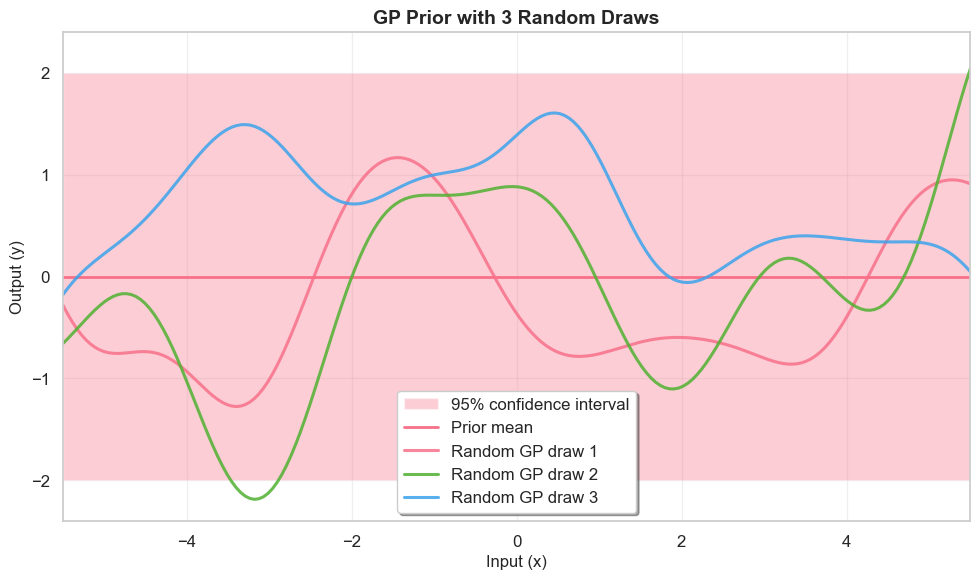

In [5]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.fill_between(
    X_prior,
    prior_mean - sigma * prior_sd,
    prior_mean + sigma * prior_sd,
    alpha=0.35,
    label="95% confidence interval",
)
ax2.plot(X_prior, prior_mean, lw=2, label="Prior mean")

draw_colors = sns.color_palette("husl", 3)
for i, color in enumerate(draw_colors, start=1):
    sample = np.random.multivariate_normal(
        prior_mean, K_prior + 1e-10 * np.eye(len(X_prior))
    )
    ax2.plot(X_prior, sample, lw=2.2, alpha=0.85,
             color=color, label=f"Random GP draw {i}")

ax2.set_title("GP Prior with 3 Random Draws", fontsize=14, fontweight="bold")
ax2.set_xlabel("Input (x)", fontsize=12)
ax2.set_ylabel("Output (y)", fontsize=12)
ax2.set_xlim(-5.5, 5.5)
ax2.set_ylim(y_min, y_max)
ax2.legend(loc="best", frameon=True, shadow=True)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## GP Posterior — Animation

The cells below compute the GP posterior as data points are added one by one and render the result as an interactive animation (no individual plots shown inline).

In [ ]:
X_train_full, y_train_full, sn_data = generate_gp_plots_data()
ell_data = 1.0
sf_data = 1.0

In [ ]:
num_points_to_add = 10

posteriors = []
posterior_y_min = np.inf
posterior_y_max = -np.inf

for n in range(1, num_points_to_add + 1):
    X_n = X_train_full[:n]
    y_n = y_train_full[:n]
    mu_n, cov_n = gp_posterior_se(X_n, y_n, X_prior, ell_data, sf_data, sn_data)
    sd_n = np.sqrt(np.diag(cov_n))
    posteriors.append((n, X_n, y_n, mu_n, sd_n))
    posterior_y_min = min(posterior_y_min, np.min(mu_n - sigma * sd_n), np.min(y_n - sn_data))
    posterior_y_max = max(posterior_y_max, np.max(mu_n + sigma * sd_n), np.max(y_n + sn_data))

posterior_margin = 0.1 * (posterior_y_max - posterior_y_min)
posterior_y_min -= posterior_margin
posterior_y_max += posterior_margin

print(f"Computed {len(posteriors)} posterior frames.")

Computed 10 posterior frames.


In [9]:
import matplotlib.animation as animation
from IPython.display import HTML

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
ci_color = colors[0]
mean_color = colors[0]

fig_anim, ax_anim = plt.subplots(figsize=(10, 6))

def draw_frame(frame_data):
    n, X_n, y_n, mu_n, sd_n = frame_data
    ax_anim.cla()
    ax_anim.fill_between(
        X_prior,
        mu_n - sigma * sd_n,
        mu_n + sigma * sd_n,
        color=ci_color,
        alpha=0.35,
        label="95% confidence interval",
    )
    ax_anim.plot(X_prior, mu_n, color=mean_color, lw=2.2, label="Posterior mean")
    ax_anim.errorbar(
        X_n, y_n, yerr=sn_data,
        fmt="o", ms=8, elinewidth=2, capsize=4,
        label="Observed data", color="steelblue",
    )
    point_label = "point" if n == 1 else "points"
    ax_anim.set_title(
        f"GP Posterior After Adding {n} Data {point_label}",
        fontsize=14, fontweight="bold",
    )
    ax_anim.set_xlabel("Input (x)", fontsize=12)
    ax_anim.set_ylabel("Output (y)", fontsize=12)
    ax_anim.set_xlim(-5.5, 5.5)
    ax_anim.set_ylim(posterior_y_min, posterior_y_max)
    ax_anim.legend(loc="best", frameon=True, shadow=True)
    ax_anim.grid(True, alpha=0.3)

anim = animation.FuncAnimation(
    fig_anim,
    draw_frame,
    frames=posteriors,
    interval=1500,  # 1.5 seconds per frame
    repeat=True,
)

plt.tight_layout()
plt.close(fig_anim)  # prevent static figure from appearing
HTML(anim.to_jshtml())